# Transformacion y preparacion de datos

En este notebook se prepara una copia del catalogo de USGS para los analisis posteriores. El archivo de `data/raw/` se conserva sin modificaciones: las transformaciones se realizan sobre `df` en memoria y al final se guarda una copia en `data/processed/`.

## 1. Importaciones y rutas


In [29]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Polygon


def find_project_root():
    """Busca la carpeta que contiene el CSV crudo."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "raw" / "sismos_usgs.csv").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto")


PROJECT_ROOT = find_project_root()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "sismos_usgs.csv"
GEO_PATH = PROJECT_ROOT / "data" / "raw" / "geodata"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_PATH = PROCESSED_DIR / "sismos_argentina_limpio.csv"

## 2. Carga y copia de trabajo

Primero se carga el archivo original y se crea una copia. De esta forma, `df_raw` sirve como referencia y todas las transformaciones se realizan sobre `df`.

In [30]:
df_raw = pd.read_csv(RAW_PATH)
df = df_raw.copy()

required_columns = {
    "id", "time", "updated", "latitude", "longitude", "depth", "mag",
}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing_columns)}")

print(f"Filas iniciales: {df.shape[0]:,}")
print(f"Columnas iniciales: {df.shape[1]}")
print(f"El archivo crudo conserva {df_raw.shape[0]:,} filas")

Filas iniciales: 10,793
Columnas iniciales: 22
El archivo crudo conserva 10,793 filas


## 3. Revision inicial de calidad

Antes de eliminar o imputar datos se observa la cantidad de nulos, duplicados y los tipos de cada columna.

In [31]:
print("Tipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum().sort_values(ascending=False))

print(f"\nDuplicados completos: {df.duplicated().sum()}")
print(f"IDs duplicados: {df['id'].duplicated().sum()}")

Tipos de datos:
time                   str
latitude           float64
longitude          float64
depth              float64
mag                float64
magType                str
nst                float64
gap                float64
dmin               float64
rms                float64
net                    str
id                     str
updated                str
place                  str
type                   str
horizontalError    float64
depthError         float64
magError           float64
magNst             float64
status                 str
locationSource         str
magSource              str
dtype: object

Valores nulos por columna:
nst                6470
magNst              536
magError            534
gap                  56
dmin                 56
horizontalError       2
rms                   2
mag                   0
magType               0
longitude             0
latitude              0
time                  0
depth                 0
net                   0
place       

## 4. Seleccion geografica de Argentina

Se repite el criterio espacial del notebook 01: un evento pertenece al area de estudio si su punto queda dentro de las provincias, la plataforma continental o el poligono antartico utilizado por el proyecto. El filtro se realiza sobre una copia y no cambia el CSV original.

In [32]:
gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)

provincias = gpd.read_file(GEO_PATH / "provinciaPolygon.shp")
plataforma = gpd.read_file(GEO_PATH / "plataforma_continentalPolygon.shp")

coordenadas_antartida = [
    (-74.0, -60.0), (-25.0, -60.0), (-25.0, -90.0),
    (-74.0, -90.0), (-74.0, -60.0),
]
poligono_antartico = Polygon(coordenadas_antartida)
poligono_nacional = (
    provincias.geometry.union_all()
    .union(plataforma.geometry.union_all())
    .union(poligono_antartico)
)

df = pd.DataFrame(
    gdf[gdf.geometry.within(poligono_nacional)].drop(columns="geometry")
)
print(f"Filas dentro del area de estudio: {df.shape[0]:,}")

Filas dentro del area de estudio: 6,429


## 5. Eliminacion de columnas poco utiles

El EDA mostro que algunas columnas tienen muchos faltantes o aportan poca informacion para esta etapa. Se eliminan solo esas columnas.

In [33]:
columns_to_drop = [
    "nst", "net", "type", "status", "locationSource", "magSource",
]
existing_columns_to_drop = [
    column for column in columns_to_drop if column in df.columns
]
df = df.drop(columns=existing_columns_to_drop)
print(f"Columnas eliminadas: {existing_columns_to_drop}")
print(f"Columnas actuales: {df.shape[1]}")

Columnas eliminadas: ['nst', 'net', 'type', 'status', 'locationSource', 'magSource']
Columnas actuales: 16


## 6. Tratamiento de registros sospechosos

No se usan indices de fila porque pueden cambiar al filtrar. Se usan los IDs estables detectados en el EDA. Si un ID no aparece en esta copia, no se elimina ninguna fila por posicion y se informa el resultado.

In [34]:
suspicious_ids = {"iscgem621613005", "iscgem620210242"}
present_suspicious_ids = set(df.loc[df["id"].isin(suspicious_ids), "id"])

df = df.loc[~df["id"].isin(present_suspicious_ids)].copy()

print(f"IDs sospechosos encontrados: {sorted(present_suspicious_ids)}")
print(f"Registros eliminados: {len(present_suspicious_ids)}")

IDs sospechosos encontrados: ['iscgem620210242', 'iscgem621613005']
Registros eliminados: 2


## 7. Fechas y variables temporales

`time` es el momento del evento y `updated` es la ultima actualizacion del registro. Convertirlas a datetime permite extraer partes de la fecha sin tratarlas como texto.

In [35]:
for column in ["time", "updated"]:
    df[column] = pd.to_datetime(df[column], utc=True, errors="raise")

df["event_year"] = df["time"].dt.year
df["event_month"] = df["time"].dt.month
df["event_day"] = df["time"].dt.day
df["event_hour"] = df["time"].dt.hour

print(df[["time", "updated", "event_year", "event_month", "event_day", "event_hour"]].head())

                              time                          updated  \
0 2026-09-14 05:03:12.877000+00:00 2026-09-14 06:21:54.040000+00:00   
1 2026-09-13 19:40:25.248000+00:00 2026-09-13 20:22:09.040000+00:00   
3 2026-09-12 11:05:46.433000+00:00 2026-09-23 07:20:17.040000+00:00   
4 2026-09-09 10:06:57.170000+00:00 2026-09-09 10:38:25.040000+00:00   
7 2026-09-08 06:50:46.470000+00:00 2026-09-08 07:06:29.040000+00:00   

   event_year  event_month  event_day  event_hour  
0        2026            9         14           5  
1        2026            9         13          19  
3        2026            9         12          11  
4        2026            9          9          10  
7        2026            9          8           6  


## 8. Tratamiento de valores faltantes

Las variables principales (`latitude`, `longitude`, `depth` y `mag`) son necesarias para el analisis, por lo que se eliminan solo las filas que realmente carecen de ellas. Para algunas variables numericas auxiliares se usa la mediana: es menos sensible que la media a valores extremos. Las variables categoricas no se rellenan inventando categorias.

In [36]:
essential_columns = ["latitude", "longitude", "depth", "mag"]
rows_before_missing = len(df)
df = df.dropna(subset=essential_columns).copy()
print(f"Filas eliminadas por faltantes esenciales: {rows_before_missing - len(df)}")

numeric_imputation_columns = [
    "gap", "dmin", "rms", "horizontalError", "magError", "magNst",
]
numeric_imputation_columns = [
    column for column in numeric_imputation_columns if column in df.columns
]

for column in numeric_imputation_columns:
    df[column] = pd.to_numeric(df[column], errors="raise")
    median = df[column].median()
    if pd.isna(median):
        raise ValueError(f"No se puede imputar {column}: mediana nula")
    df[column] = df[column].fillna(median)

print("Nulos despues del tratamiento:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Filas eliminadas por faltantes esenciales: 0
Nulos despues del tratamiento:
time         0
latitude     0
longitude    0
depth        0
mag          0
magType      0
gap          0
dmin         0
rms          0
id           0
dtype: int64


## 9. Comprobaciones finales

Estas comprobaciones confirman que la transformacion conserva un identificador unico, fechas validas y las variables necesarias para los analisis.

In [37]:
assert not df["id"].duplicated().any()
assert not df.duplicated().any()
assert isinstance(df["time"].dtype, pd.DatetimeTZDtype)
assert isinstance(df["updated"].dtype, pd.DatetimeTZDtype)
assert df[essential_columns].notna().all().all()
assert df[numeric_imputation_columns].notna().all().all()

print(f"Resultado final: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Duplicados completos: {df.duplicated().sum()}")
print(f"Nulos totales: {int(df.isna().sum().sum())}")
display(df.describe(include="all").transpose())

Resultado final: 6,427 filas x 20 columnas
Duplicados completos: 0
Nulos totales: 0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
time,6427,NaN,NaN,NaN,2021-10-28 08:01:47.987145+00:00,2016-09-15 01:06:30.870000+00:00,2020-01-28 05:39:44.956500+00:00,2021-09-06 17:48:31.156000+00:00,2023-10-20 01:34:04.014000+00:00,2026-09-14 05:03:12.877000+00:00,NaN
latitude,6427.0,NaN,NaN,NaN,-45.511352,-65.3437,-58.75835,-55.8493,-24.91715,-21.8795,15.800398
longitude,6427.0,NaN,NaN,NaN,-45.242866,-73.2752,-66.93575,-30.8196,-26.05445,-25.0017,19.741032
depth,6427.0,NaN,NaN,NaN,90.171409,1.0,10.0,43.35,167.6605,626.01,94.046523
mag,6427.0,NaN,NaN,NaN,4.588486,2.3,4.3,4.5,4.8,8.1,0.395333
magType,6427,7,mb,5648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gap,6427.0,NaN,NaN,NaN,86.627509,12.0,58.0,79.0,107.0,292.0,40.139847
dmin,6427.0,NaN,NaN,NaN,5.386387,0.041,1.615,4.844,7.453,32.456,4.686927
rms,6427.0,NaN,NaN,NaN,0.751897,0.09,0.59,0.73,0.9,2.48,0.234337
id,6427,6427,us7000than,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Visualizaciones de control

El histograma permite revisar la forma de la distribucion de magnitudes. El grafico de dispersion ayuda a detectar combinaciones de magnitud y profundidad que puedan parecer absurdas despues de la transformacion.

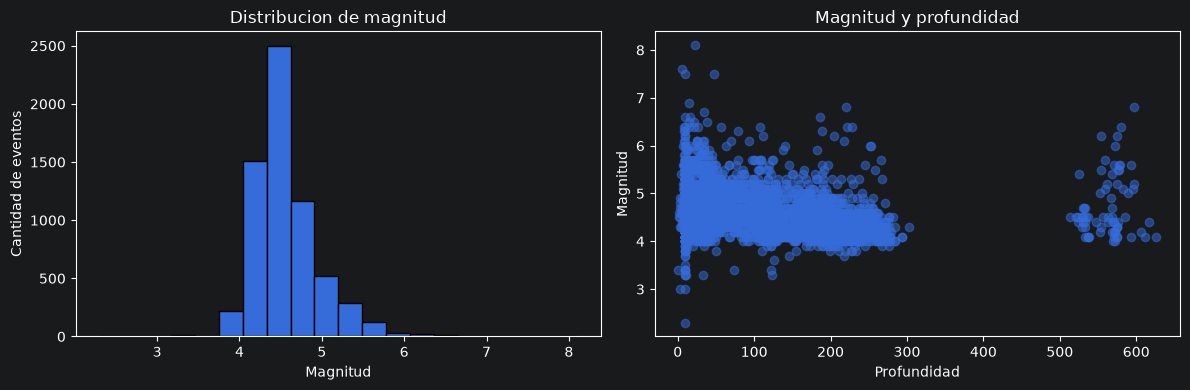

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["mag"], bins=20, edgecolor="black")
axes[0].set_title("Distribucion de magnitud")
axes[0].set_xlabel("Magnitud")
axes[0].set_ylabel("Cantidad de eventos")

axes[1].scatter(df["depth"], df["mag"], alpha=0.5)
axes[1].set_title("Magnitud y profundidad")
axes[1].set_xlabel("Profundidad")
axes[1].set_ylabel("Magnitud")

plt.tight_layout()
plt.show()

## 11. Guardado del dataset procesado

Se guarda una copia procesada en `data/processed/` para que las siguientes etapas puedan reutilizarla sin ejecutar nuevamente toda la transformacion. El archivo crudo de `data/raw/` no se modifica.

In [39]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)

## Conclusion

El DataFrame `df` y el archivo procesado quedan listos para continuar con la etapa de visualizacion.